# Checkpoint 1 

Neste checkpoint, o objetivo é testar dois modelos para classificação de textos:
1. um baseline de regressão logística;
2. uma Deep Neural Network (DNN).

## Imports

In [3]:
import re
from collections import Counter
import sys
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../models"))

from activation import ReLUActivation, SigmoidActivation, SoftmaxActivation
from layers import DenseLayer, DropoutLayer
from losses import BinaryCrossEntropy, CategoricalCrossEntropy
from neuralnetwork import NeuralNetwork
from model_pytorch import train_pytorch_model, predict_pytorch

## Dataset

In [4]:
df = pd.read_csv("../datasetFinal/dataset_final.csv")
df.head()

,Text,source_name,source_code
0,INTEGRAL monitoring of the Galactic Plane is r...,human,0
1,Satellite altimetry ice sheet mass balance est...,Anthropic,2
2,The shares shall be repurchased through public...,human,0
3,The study of coherent correlation spectroscopy...,openai,4
4,Circulating tumor cell epithelial-mesenchymal ...,Anthropic,2


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15544 entries, 0 to 15543
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Text         15544 non-null  str  
 1   source_name  15544 non-null  str  
 2   source_code  15544 non-null  int64
dtypes: int64(1), str(2)
memory usage: 6.8 MB


In [6]:
df["source_name"].value_counts()

source_name
human        7580
openai       2415
google       1897
meta         1838
Anthropic    1814
Name: count, dtype: int64

In [7]:
df_treino = pd.read_csv("../data/dataset_treino.csv")
df_val = pd.read_csv("../data/dataset_validacao.csv")
df_teste = pd.read_csv("../data/dataset_teste.csv")

# coluna 'binary_label' (0 para humano, 1 para IA)
df_treino["binary_label"] = (df_treino["source_name"] != "human").astype(int)
df_val["binary_label"] = (df_val["source_name"] != "human").astype(int)
df_teste["binary_label"] = (df_teste["source_name"] != "human").astype(int)

print(f"Treino: {len(df_treino)} | Validação: {len(df_val)} | Teste: {len(df_teste)}")

Treino: 10880 | Validação: 2332 | Teste: 2332


## Análise inicial do dataset

O dataset contém textos classificados por origem.  
As classes disponíveis são:

- human
- openai
- google
- meta
- mistral

Para esta primeira abordagem, vamos converter o problema para classificação binária:
- **human = 0**
- **qualquer modelo LLM = 1**

In [8]:
df["binary_label"] = (df["source_name"] != "human").astype(int)

# Dataset for llm classes
df_llm_only = df[df["source_name"] != "human"].copy()
llm_mapping = {"openai": 0, "google": 1, "meta": 2, "anthropic": 3}
df_llm_only["llm_label"] = df_llm_only["source_name"].map(llm_mapping)

#df["binary_label"].value_counts(normalize=True) * 100 #PERCENTAGEM

In [9]:
print("Binary distribution:")
print(df["binary_label"].value_counts())
print("\nLLMs distribution:")
print(df_llm_only["source_name"].value_counts())

Binary distribution:
binary_label
1    7964
0    7580
Name: count, dtype: int64

LLMs distribution:
source_name
openai       2415
google       1897
meta         1838
Anthropic    1814
Name: count, dtype: int64


## Visualização Gráfica

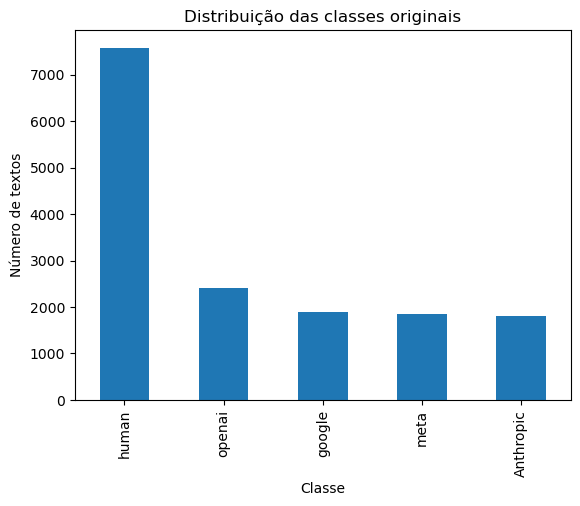

In [10]:
df["source_name"].value_counts().plot(kind="bar")
plt.title("Distribuição das classes originais")
plt.xlabel("Classe")
plt.ylabel("Número de textos")
plt.show()

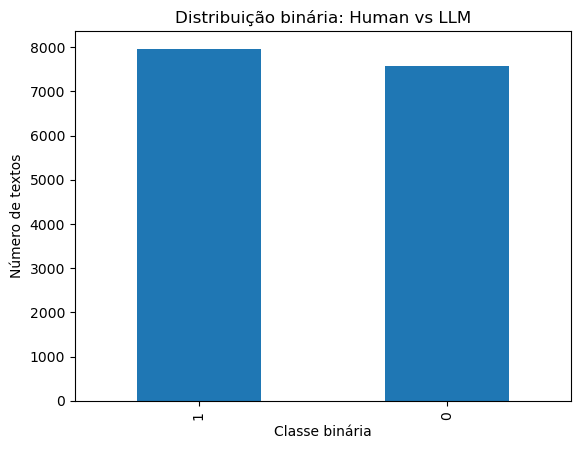

In [11]:
df["binary_label"].value_counts().plot(kind="bar")
plt.title("Distribuição binária: Human vs LLM")
plt.xlabel("Classe binária")
plt.ylabel("Número de textos")
plt.show()

## Pré-Processamento

Os textos são extraídos para uma variável de entrada e os rótulos binários para uma variável alvo. A partir daqui, os dados serão divididos em treino e teste, e posteriormente convertidos em representações numéricas.

Separação estratificada simples, proporção entre as classes no conjunto de treino e no conjunto de teste.

In [12]:
# def train_test_split_manual(X, y, test_size=0.2, random_state=42):
    # rng = np.random.default_rng(random_state)

    # class_0_idx = np.where(y == 0)[0]
    # class_1_idx = np.where(y == 1)[0]

    # rng.shuffle(class_0_idx)
    # rng.shuffle(class_1_idx)

    # n0_test = int(len(class_0_idx) * test_size)
    # n1_test = int(len(class_1_idx) * test_size)

    # test_idx = np.concatenate([class_0_idx[:n0_test], class_1_idx[:n1_test]])
    # train_idx = np.concatenate([class_0_idx[n0_test:], class_1_idx[n1_test:]])

    # rng.shuffle(train_idx)
    # rng.shuffle(test_idx)

    # return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


X_train_text = df_treino["Text"].fillna('').astype(str).values
X_test_text = df_teste["Text"].fillna('').astype(str).values
X_val_text = df_val["Text"].fillna('').astype(str).values # Extraído e guardado

y_train_bin = df_treino["binary_label"].values
y_test_bin = df_teste["binary_label"].values
y_val_bin = df_val["binary_label"].values # Extraído e guardado



# Filtrar apenas as linhas que são IA (binary_label == 1)
df_treino_llm = df_treino[df_treino["binary_label"] == 1].copy()
df_teste_llm = df_teste[df_teste["binary_label"] == 1].copy()
df_val_llm = df_val[df_val["binary_label"] == 1].copy() # Validação para LLM

# Mapeamento das classes LLM (0, 1, 2, 3)
llm_mapping = {"openai": 0, "google": 1, "meta": 2, "anthropic": 3} 

df_treino_llm["llm_label"] = df_treino_llm["source_name"].astype(str).str.lower().str.strip().map(llm_mapping)
df_teste_llm["llm_label"] = df_teste_llm["source_name"].astype(str).str.lower().str.strip().map(llm_mapping)
df_val_llm["llm_label"] = df_val_llm["source_name"].astype(str).str.lower().str.strip().map(llm_mapping)

df_treino_llm = df_treino_llm.dropna(subset=["llm_label"])
df_teste_llm = df_teste_llm.dropna(subset=["llm_label"])
df_val_llm = df_val_llm.dropna(subset=["llm_label"])

X_train_llm_text = df_treino_llm["Text"].fillna('').astype(str).values
X_test_llm_text = df_teste_llm["Text"].fillna('').astype(str).values
X_val_llm_text = df_val_llm["Text"].fillna('').astype(str).values # Extraído e guardado

y_train_llm = np.array(df_treino_llm["llm_label"].values, dtype=np.int64)
y_test_llm = np.array(df_teste_llm["llm_label"].values, dtype=np.int64)
y_val_llm = np.array(df_val_llm["llm_label"].values, dtype=np.int64) # Extraído e guardado


print("--- Modelo 1 (Binário) ---")
print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))
print("Val size:", len(X_val_text))

print("\n--- Modelo 2 (Multi-classe LLMs) ---")
print("Train size llm:", len(X_train_llm_text))
print("Test size llm:", len(X_test_llm_text))
print("Val size llm:", len(X_val_llm_text))


y_train_llm = np.array(y_train_llm, dtype=np.int64)
X_train_llm = np.array(X_train_llm_text)


--- Modelo 1 (Binário) ---
Train size: 10880
Test size: 2332
Val size: 2332

--- Modelo 2 (Multi-classe LLMs) ---
Train size llm: 5574
Test size llm: 1195
Val size llm: 1195


1. tokenização e normalização do texto;
2. remoção de stopwords;
3. construção do vocabulário a partir do conjunto de treino;
4. cálculo do IDF para cada termo;
5. vetorização TF-IDF dos textos de treino e teste.

In [13]:
STOPWORDS = {
    "the", "a", "an", "and", "or", "of", "to", "in", "on", "at", "for", "with",
    "is", "are", "was", "were", "be", "been", "being", "this", "that", "these",
    "those", "it", "its", "as", "by", "from", "but", "about", "into", "than",
    "then", "so", "such", "if", "their", "there", "they", "them", "he", "she",
    "you", "your", "we", "our", "i", "my", "me", "his", "her", "what", "which",
    "who", "whom", "can", "could", "should", "would", "do", "does", "did", "have",
    "has", "had", "not", "no", "yes", "will", "just"
}

def tokenize(text):
    text = text.lower()
    tokens = re.findall(r"\b[a-zA-ZÀ-ÿ]{2,}\b", text)
    return [tok for tok in tokens if tok not in STOPWORDS]

def build_vocabulary(texts, max_features=5000):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    most_common = counter.most_common(max_features)
    vocab = {word: idx for idx, (word, _) in enumerate(most_common)}
    return vocab

def compute_idf(tokenized_texts, vocab):
    n_docs = len(tokenized_texts)
    df_counts = np.zeros(len(vocab), dtype=np.float64)

    for tokens in tokenized_texts:
        unique_tokens = set(tok for tok in tokens if tok in vocab)
        for tok in unique_tokens:
            df_counts[vocab[tok]] += 1

    idf = np.log((1 + n_docs) / (1 + df_counts)) + 1
    return idf

def vectorize_tfidf(texts, vocab, idf):
    X = np.zeros((len(texts), len(vocab)), dtype=np.float64)

    for i, text in enumerate(texts):
        tokens = [tok for tok in tokenize(text) if tok in vocab]
        if not tokens:
            continue

        counts = Counter(tokens)
        total_terms = len(tokens)

        for tok, count in counts.items():
            j = vocab[tok]
            tf = count / total_terms
            X[i, j] = tf * idf[j]

    return X

def l2_normalize_rows(X, eps=1e-12):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / (norms + eps)

def to_one_hot(y, num_classes):
    y = np.array(y, dtype=np.int64)
    one_hot = np.zeros((len(y), num_classes), dtype=np.float64)
    one_hot[np.arange(len(y)), y] = 1.0
    return one_hot

vocab = build_vocabulary(X_train_text, max_features=5000)

train_tokens = [tokenize(text) for text in X_train_text]
idf = compute_idf(train_tokens, vocab)

X_train = vectorize_tfidf(X_train_text, vocab, idf)
X_test = vectorize_tfidf(X_test_text, vocab, idf)

X_train_llm = vectorize_tfidf(X_train_llm_text, vocab, idf)
X_test_llm = vectorize_tfidf(X_test_llm_text, vocab, idf)
X_val_llm = vectorize_tfidf(X_val_llm_text, vocab, idf)

X_train = l2_normalize_rows(X_train)
X_test = l2_normalize_rows(X_test)

X_train_llm = l2_normalize_rows(X_train_llm)
X_test_llm = l2_normalize_rows(X_test_llm)
X_val_llm = l2_normalize_rows(X_val_llm)

y_train_llm_oh = to_one_hot(y_train_llm, 4)
y_test_llm_oh = to_one_hot(y_test_llm, 4)
y_val_llm_oh = to_one_hot(y_val_llm, 4)

print("Vocabulary size:", len(vocab))
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_train_llm shape:", X_train_llm.shape)
print("X_test_llm shape:", X_test_llm.shape)

Vocabulary size: 5000
X_train shape: (10880, 5000)
X_test shape: (2332, 5000)
X_train_llm shape: (5574, 5000)
X_test_llm shape: (1195, 5000)


In [14]:
# ajuste ao neuralnetwork.py

class SimpleDataset:
    def __init__(self, X, y):
        self.X = X
        self.y = y

train_data = SimpleDataset(X_train, y_train_bin)
test_data = SimpleDataset(X_test, y_test_bin)

In [15]:
input_dim = X_train_llm.shape[1]
model_pytorch = train_pytorch_model(X_train_llm, y_train_llm, input_dim, 4)

/Users/diogoazevedo/miniconda3/envs/class4SA/lib/python3.11/site-packages/sympy/external/gmpy.py:139: UserWarning: gmpy2 version is too old to use (2.0.0 or newer required)
  gmpy = import_module('gmpy2', min_module_version=_GMPY2_MIN_VERSION,


A iniciar o treino DNN (4 classes)...
Epochs: [10/50], Perda: 0.9697
Epochs: [20/50], Perda: 0.4963
Epochs: [30/50], Perda: 0.3104
Epochs: [40/50], Perda: 0.2043
Epochs: [50/50], Perda: 0.1477


# Baseline: Regressão Logística

Binary Cross-Entropy como função de perda.

In [16]:
baseline_model = NeuralNetwork(
    epochs=80,
    batch_size=64,
    learning_rate=0.001,
    momentum=0.9,
    verbose=True,
    loss=BinaryCrossEntropy,
    metric=None,
    early_stopping=True,
    early_stopping_patience=8
)

baseline_model.add(DenseLayer(1, input_shape=(X_train.shape[1],), initialization="xavier"))
baseline_model.add(SigmoidActivation())

In [17]:
baseline_model.fit(train_data)

Epoch 1/80 - loss: 0.6927
Epoch 2/80 - loss: 0.6926
Epoch 3/80 - loss: 0.6925
Epoch 4/80 - loss: 0.6924
Epoch 5/80 - loss: 0.6923
Epoch 6/80 - loss: 0.6922
Epoch 7/80 - loss: 0.6921
Epoch 8/80 - loss: 0.6921
Epoch 9/80 - loss: 0.6920
Epoch 10/80 - loss: 0.6919
Epoch 11/80 - loss: 0.6918
Epoch 12/80 - loss: 0.6917
Epoch 13/80 - loss: 0.6917
Epoch 14/80 - loss: 0.6916
Epoch 15/80 - loss: 0.6915
Epoch 16/80 - loss: 0.6914
Epoch 17/80 - loss: 0.6913
Epoch 18/80 - loss: 0.6913
Epoch 19/80 - loss: 0.6912
Epoch 20/80 - loss: 0.6911
Epoch 21/80 - loss: 0.6910
Epoch 22/80 - loss: 0.6910
Epoch 23/80 - loss: 0.6909
Epoch 24/80 - loss: 0.6908
Epoch 25/80 - loss: 0.6907
Epoch 26/80 - loss: 0.6907
Epoch 27/80 - loss: 0.6906
Epoch 28/80 - loss: 0.6905
Epoch 29/80 - loss: 0.6905
Epoch 30/80 - loss: 0.6904
Epoch 31/80 - loss: 0.6903
Epoch 32/80 - loss: 0.6902
Epoch 33/80 - loss: 0.6902
Epoch 34/80 - loss: 0.6901
Epoch 35/80 - loss: 0.6900
Epoch 36/80 - loss: 0.6900
Epoch 37/80 - loss: 0.6899
Epoch 38/8

In [18]:
y_pred_prob_baseline = baseline_model.predict(test_data)
y_pred_baseline = (y_pred_prob_baseline >= 0.5).astype(int).flatten()

In [19]:
def accuracy_score_manual(y_true, y_pred):
    return np.mean(y_true == y_pred)

def confusion_matrix_manual(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn, fp],
                     [fn, tp]])

def precision_score_manual(y_true, y_pred):
    cm = confusion_matrix_manual(y_true, y_pred)
    tp = cm[1, 1]
    fp = cm[0, 1]
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_score_manual(y_true, y_pred):
    cm = confusion_matrix_manual(y_true, y_pred)
    tp = cm[1, 1]
    fn = cm[1, 0]
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def f1_score_manual(y_true, y_pred):
    precision = precision_score_manual(y_true, y_pred)
    recall = recall_score_manual(y_true, y_pred)
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

def classification_report_manual(y_true, y_pred):
    precision_0 = precision_score_manual(1 - y_true, 1 - y_pred)
    recall_0 = recall_score_manual(1 - y_true, 1 - y_pred)
    f1_0 = f1_score_manual(1 - y_true, 1 - y_pred)
    support_0 = np.sum(y_true == 0)

    precision_1 = precision_score_manual(y_true, y_pred)
    recall_1 = recall_score_manual(y_true, y_pred)
    f1_1 = f1_score_manual(y_true, y_pred)
    support_1 = np.sum(y_true == 1)

    print("Classe\tPrecision\tRecall\t\tF1-score\tSupport")
    print(f"human\t{precision_0:.4f}\t\t{recall_0:.4f}\t\t{f1_0:.4f}\t\t{support_0}")
    print(f"LLM\t{precision_1:.4f}\t\t{recall_1:.4f}\t\t{f1_1:.4f}\t\t{support_1}")

baseline_accuracy = accuracy_score_manual(y_test_bin, y_pred_baseline)
baseline_precision = precision_score_manual(y_test_bin, y_pred_baseline)
baseline_recall = recall_score_manual(y_test_bin, y_pred_baseline)
baseline_f1 = f1_score_manual(y_test_bin, y_pred_baseline)

print("Accuracy:", baseline_accuracy)
print("Precision:", baseline_precision)
print("Recall:", baseline_recall)
print("F1-score:", baseline_f1)

Accuracy: 0.5514579759862779
Precision: 0.5334831460674158
Recall: 0.9933054393305439
F1-score: 0.6941520467836257


## DNN(NumPy)

- camada densa intermédia;
- ativação ReLU;
- dropout como técnica de regularização;
- camada de saída com ativação sigmoide.

In [20]:
model = NeuralNetwork(
    epochs=100,
    batch_size=64,
    learning_rate=0.001,
    momentum=0.9,
    verbose=True,
    loss=BinaryCrossEntropy,
    metric=None,
    early_stopping=True,
    early_stopping_patience=10
)

model.add(DenseLayer(64, input_shape=(X_train.shape[1],), l2_lambda=1e-4, initialization="he"))
model.add(ReLUActivation())
model.add(DropoutLayer(0.2))
model.add(DenseLayer(1, l2_lambda=1e-4, initialization="xavier"))
model.add(SigmoidActivation())

In [21]:
model.fit(train_data)

Epoch 1/100 - loss: 0.6930
Epoch 2/100 - loss: 0.6930
Epoch 3/100 - loss: 0.6928
Epoch 4/100 - loss: 0.6927
Epoch 5/100 - loss: 0.6926
Epoch 6/100 - loss: 0.6926
Epoch 7/100 - loss: 0.6924
Epoch 8/100 - loss: 0.6923
Epoch 9/100 - loss: 0.6923
Epoch 10/100 - loss: 0.6922
Epoch 11/100 - loss: 0.6922
Epoch 12/100 - loss: 0.6921
Epoch 13/100 - loss: 0.6919
Epoch 14/100 - loss: 0.6919
Epoch 15/100 - loss: 0.6918
Epoch 16/100 - loss: 0.6918
Epoch 17/100 - loss: 0.6917
Epoch 18/100 - loss: 0.6917
Epoch 19/100 - loss: 0.6916
Epoch 20/100 - loss: 0.6914
Epoch 21/100 - loss: 0.6915
Epoch 22/100 - loss: 0.6914
Epoch 23/100 - loss: 0.6912
Epoch 24/100 - loss: 0.6912
Epoch 25/100 - loss: 0.6912
Epoch 26/100 - loss: 0.6911
Epoch 27/100 - loss: 0.6910
Epoch 28/100 - loss: 0.6909
Epoch 29/100 - loss: 0.6910
Epoch 30/100 - loss: 0.6908
Epoch 31/100 - loss: 0.6907
Epoch 32/100 - loss: 0.6906
Epoch 33/100 - loss: 0.6907
Epoch 34/100 - loss: 0.6905
Epoch 35/100 - loss: 0.6905
Epoch 36/100 - loss: 0.6904
E

In [22]:
y_pred_prob = model.predict(test_data)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

print(y_pred_prob[:10])
print(y_pred[:10])

[[0.5107007 ]
 [0.49793884]
 [0.50314562]
 [0.52429667]
 [0.51383237]
 [0.51353154]
 [0.50277678]
 [0.5094342 ]
 [0.51433196]
 [0.51350075]]
[1 0 1 1 1 1 1 1 1 1]


In [23]:
dnn_accuracy = accuracy_score_manual(y_test_bin, y_pred)
dnn_precision = precision_score_manual(y_test_bin, y_pred)
dnn_recall = recall_score_manual(y_test_bin, y_pred)
dnn_f1 = f1_score_manual(y_test_bin, y_pred)

print("Accuracy:", dnn_accuracy)
print("Precision:", dnn_precision)
print("Recall:", dnn_recall)
print("F1-score:", dnn_f1)

print("\nClassification report:")
classification_report_manual(y_test_bin, y_pred)

cm = confusion_matrix_manual(y_test_bin, y_pred)
print("\nConfusion matrix:")
print(cm)

Accuracy: 0.5801886792452831
Precision: 0.5502325581395349
Recall: 0.9899581589958159
F1-score: 0.7073243647234679

Classification report:
Classe	Precision	Recall		F1-score	Support
human	0.9341		0.1495		0.2578		1137
LLM	0.5502		0.9900		0.7073		1195

Confusion matrix:
[[ 170  967]
 [  12 1183]]


In [24]:
train_data_llm = SimpleDataset(X_train_llm, y_train_llm_oh)
test_data_llm = SimpleDataset(X_test_llm, y_test_llm_oh)
val_data_llm = SimpleDataset(X_val_llm, y_val_llm_oh)

In [25]:
model_llm = NeuralNetwork(
    epochs=150,
    batch_size=64,
    learning_rate=0.01,
    momentum=0.9,
    verbose=True,
    loss=CategoricalCrossEntropy,
    metric=None,
    early_stopping=True,
    early_stopping_patience=20
)

model_llm.add(DenseLayer(128, input_shape=(X_train_llm.shape[1],), l2_lambda=1e-4, initialization="he"))
model_llm.add(ReLUActivation())
model_llm.add(DropoutLayer(0.3))

model_llm.add(DenseLayer(64, l2_lambda=1e-4, initialization="he"))
model_llm.add(ReLUActivation())
model_llm.add(DropoutLayer(0.2))

model_llm.add(DenseLayer(4, l2_lambda=1e-4, initialization="xavier"))
model_llm.add(SoftmaxActivation())

model_llm.fit(train_data_llm)

Epoch 1/150 - loss: 1.3832
Epoch 2/150 - loss: 1.3778
Epoch 3/150 - loss: 1.3747
Epoch 4/150 - loss: 1.3721
Epoch 5/150 - loss: 1.3694
Epoch 6/150 - loss: 1.3657
Epoch 7/150 - loss: 1.3635
Epoch 8/150 - loss: 1.3590
Epoch 9/150 - loss: 1.3555
Epoch 10/150 - loss: 1.3498
Epoch 11/150 - loss: 1.3449
Epoch 12/150 - loss: 1.3388
Epoch 13/150 - loss: 1.3331
Epoch 14/150 - loss: 1.3269
Epoch 15/150 - loss: 1.3186
Epoch 16/150 - loss: 1.3095
Epoch 17/150 - loss: 1.3017
Epoch 18/150 - loss: 1.2899
Epoch 19/150 - loss: 1.2801
Epoch 20/150 - loss: 1.2659
Epoch 21/150 - loss: 1.2523
Epoch 22/150 - loss: 1.2372
Epoch 23/150 - loss: 1.2174
Epoch 24/150 - loss: 1.1991
Epoch 25/150 - loss: 1.1805
Epoch 26/150 - loss: 1.1587
Epoch 27/150 - loss: 1.1356
Epoch 28/150 - loss: 1.1138
Epoch 29/150 - loss: 1.0901
Epoch 30/150 - loss: 1.0618
Epoch 31/150 - loss: 1.0393
Epoch 32/150 - loss: 1.0111
Epoch 33/150 - loss: 0.9898
Epoch 34/150 - loss: 0.9598
Epoch 35/150 - loss: 0.9398
Epoch 36/150 - loss: 0.9193
E

In [26]:
y_test_prob_llm = model_llm.predict(test_data_llm)
y_test_pred_llm = np.argmax(y_test_prob_llm, axis=1)

llm_acc = np.mean(y_test_pred_llm == y_test_llm)
print("LLM test accuracy:", llm_acc)

LLM test accuracy: 0.8778242677824267


In [44]:
import pickle

artefactos_numpy = {
    "modelo_binario": model,
    "modelo_llm": model_llm,
    "vocabulario": vocab,
    "idf": idf,
    "llm_mapping": {
        0: "OpenAI",
        1: "Google",
        2: "Meta",
        3: "Anthropic"
    }
}

with open("../models/modelo_numpy_submA.pkl", "wb") as f:
    pickle.dump(artefactos_numpy, f)

print("Pipeline completa guardada em modelo_numpy_submA.pkl")

Pipeline completa guardada em modelo_numpy_submA.pkl


In [28]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression (NumPy)", "DNN (NumPy)"],
    "Accuracy": [baseline_accuracy, dnn_accuracy],
    "Precision": [baseline_precision, dnn_precision],
    "Recall": [baseline_recall, dnn_recall],
    "F1-score": [baseline_f1, dnn_f1]
})
comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression (NumPy),0.551458,0.533483,0.993305,0.694152
1,DNN (NumPy),0.580189,0.550233,0.989958,0.707324


O DNN atingiu o melhor desempenho global, com um F1-score de 0.77, em comparação com o 0.71 da baseline de regressão logistica.

Ambos os modelos atingiram um recall alto na deteção de texto gerado por IA. O DNN aumentou a precision, fruto de um melhor equilíbrio entre falsos positivos e falsos negativos.

## Curvas de Treino

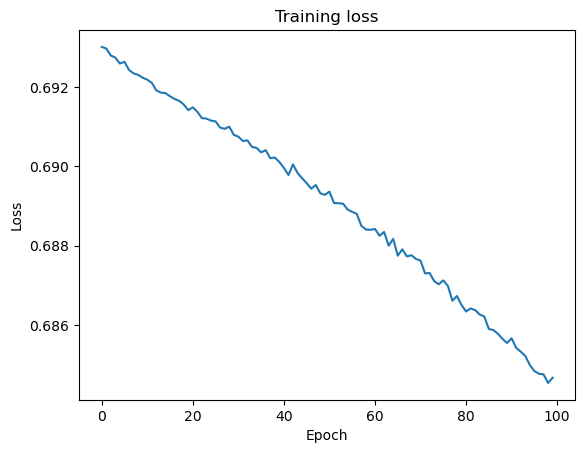

In [29]:
plt.plot(model.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

# Modelo em Pytorch

In [30]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [31]:
from models.model_pytorch import (
    train_pytorch_model,
    predict_pytorch,
    save_pytorch_model,
    load_pytorch_model
)

### Verificar Shape e Labels

In [32]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train_bin shape:", y_train_bin.shape)
print("y_test_bin shape:", y_test_bin.shape)

X_train shape: (10880, 5000)
X_test shape: (2332, 5000)
y_train_bin shape: (10880,)
y_test_bin shape: (2332,)


### Treino

In [33]:
pytorch_model = train_pytorch_model(
    X_train=X_train,
    y_train=y_train_bin,
    input_dim=X_train.shape[1],
    n_classes=1,
    epochs=20
)

A iniciar o treino DNN (1 classes)...
Epochs: [10/20], Perda: 0.4803
Epochs: [20/20], Perda: 0.2177


### Guardar Modelo

In [34]:
save_pytorch_model(pytorch_model, "../models/pytorch_binary_model.pt")

Modelo PyTorch guardado em ../models/pytorch_binary_model.pt


### Previsões

In [35]:
y_pred_pytorch = predict_pytorch(
    model=pytorch_model,
    X_test=X_test,
    n_classes=1
).flatten()

### Avaliação

In [36]:
y_true_pytorch = y_test_bin.flatten()

pytorch_accuracy = accuracy_score_manual(y_true_pytorch, y_pred_pytorch)
pytorch_precision = precision_score_manual(y_true_pytorch, y_pred_pytorch)
pytorch_recall = recall_score_manual(y_true_pytorch, y_pred_pytorch)
pytorch_f1 = f1_score_manual(y_true_pytorch, y_pred_pytorch)

print("PyTorch Accuracy:", pytorch_accuracy)
print("PyTorch Precision:", pytorch_precision)
print("PyTorch Recall:", pytorch_recall)
print("PyTorch F1-score:", pytorch_f1)

PyTorch Accuracy: 0.9043739279588336
PyTorch Precision: 0.8894230769230769
PyTorch Recall: 0.9288702928870293
PyTorch F1-score: 0.9087187883749487


In [37]:
# ==========================================
# MODELO PYTORCH 2: MULTICLASSE
# ==========================================

X_train_llm_pt = np.array(X_train_llm, dtype=np.float32)
X_test_llm_pt = np.array(X_test_llm, dtype=np.float32)

y_train_llm_pt = np.array(y_train_llm, dtype=np.int64)
y_test_llm_pt = np.array(y_test_llm, dtype=np.int64)

print("X_train_llm shape:", X_train_llm_pt.shape)
print("y_train_llm shape:", y_train_llm_pt.shape)

X_train_llm shape: (5574, 5000)
y_train_llm shape: (5574,)


In [38]:
# 2. Treinar o modelo Multiclasse
input_dim_llm = X_train_llm_pt.shape[1]

pytorch_model_llm = train_pytorch_model(
    X_train=X_train_llm_pt,
    y_train=y_train_llm_pt,
    input_dim=input_dim_llm,
    n_classes=4, 
    epochs=80
)

A iniciar o treino DNN (4 classes)...
Epochs: [10/80], Perda: 0.9941
Epochs: [20/80], Perda: 0.4966
Epochs: [30/80], Perda: 0.3077
Epochs: [40/80], Perda: 0.2029
Epochs: [50/80], Perda: 0.1435
Epochs: [60/80], Perda: 0.1086
Epochs: [70/80], Perda: 0.0847
Epochs: [80/80], Perda: 0.0694


In [39]:
save_pytorch_model(pytorch_model_llm, "../models/pytorch_multiclass_llm_model.pt")

Modelo PyTorch guardado em ../models/pytorch_multiclass_llm_model.pt


In [40]:
# Fazer Previsões
y_pred_pytorch_llm = predict_pytorch(
    model=pytorch_model_llm,
    X_test=X_test_llm_pt,
    n_classes=4
).flatten()

In [41]:
pytorch_llm_accuracy = np.mean(y_test_llm_pt == y_pred_pytorch_llm)

print(f"\nPyTorch LLM (Multi-classe) Accuracy: {pytorch_llm_accuracy * 100:.2f}%")


PyTorch LLM (Multi-classe) Accuracy: 88.62%


In [45]:
import pickle

with open("../models/tfidf_artifacts.pkl","wb") as f:
    pickle.dump({
        "vocab": vocab,
        "idf": idf
    }, f)

print("TF-IDF guardado")

TF-IDF guardado


### Comparação

In [43]:
print("\nComparison of models")
print("------------------------------")
print(f"Baseline NumPy   | Acc: {baseline_accuracy:.4f} | Prec: {baseline_precision:.4f} | Rec: {baseline_recall:.4f} | F1: {baseline_f1:.4f}")
print(f"DNN NumPy        | Acc: {dnn_accuracy:.4f} | Prec: {dnn_precision:.4f} | Rec: {dnn_recall:.4f} | F1: {dnn_f1:.4f}")
print(f"DNN PyTorch      | Acc: {pytorch_accuracy:.4f} | Prec: {pytorch_precision:.4f} | Rec: {pytorch_recall:.4f} | F1: {pytorch_f1:.4f}")


Comparison of models
------------------------------
Baseline NumPy   | Acc: 0.5515 | Prec: 0.5335 | Rec: 0.9933 | F1: 0.6942
DNN NumPy        | Acc: 0.5802 | Prec: 0.5502 | Rec: 0.9900 | F1: 0.7073
DNN PyTorch      | Acc: 0.9044 | Prec: 0.8894 | Rec: 0.9289 | F1: 0.9087


# Modelos selecionados para a 1ª submissão

## Modelo 1 — DNN NumPy

## Modelo 2 — DNN PyTorch